# 제품 카테고리별 매출
- 어떤 제품군의 총 매출과 평균 매출이 높고 적은지를 판단.

In [5]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [6]:
# MySQL 데이터베이스 연결 설정
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password= 'doruru0614!@#',  # 실제 비밀번호로 변경하세요
    database='classicmodels'
)

In [7]:
# 제품 카테고리별 매출 분석 쿼리 실행
# 각 제품 라인(productLine)에 대한 총 매출(total_sales)과 평균 매출(average_sales)을 계산하는 쿼리
category_sales_query = """
SELECT 
    p.productLine, 
    SUM(od.quantityOrdered * od.priceEach) AS total_sales,
    AVG(od.quantityOrdered * od.priceEach) AS average_sales
FROM 
    products p
JOIN 
    orderdetails od ON p.productCode = od.productCode
GROUP BY 
    p.productLine
ORDER BY 
    total_sales DESC;

"""

In [8]:
# SQL 쿼리 실행 및 결과 DataFrame으로 변환
category_sales_df = pd.read_sql_query(category_sales_query, conn)

In [9]:
# 연결 종료
conn.close()

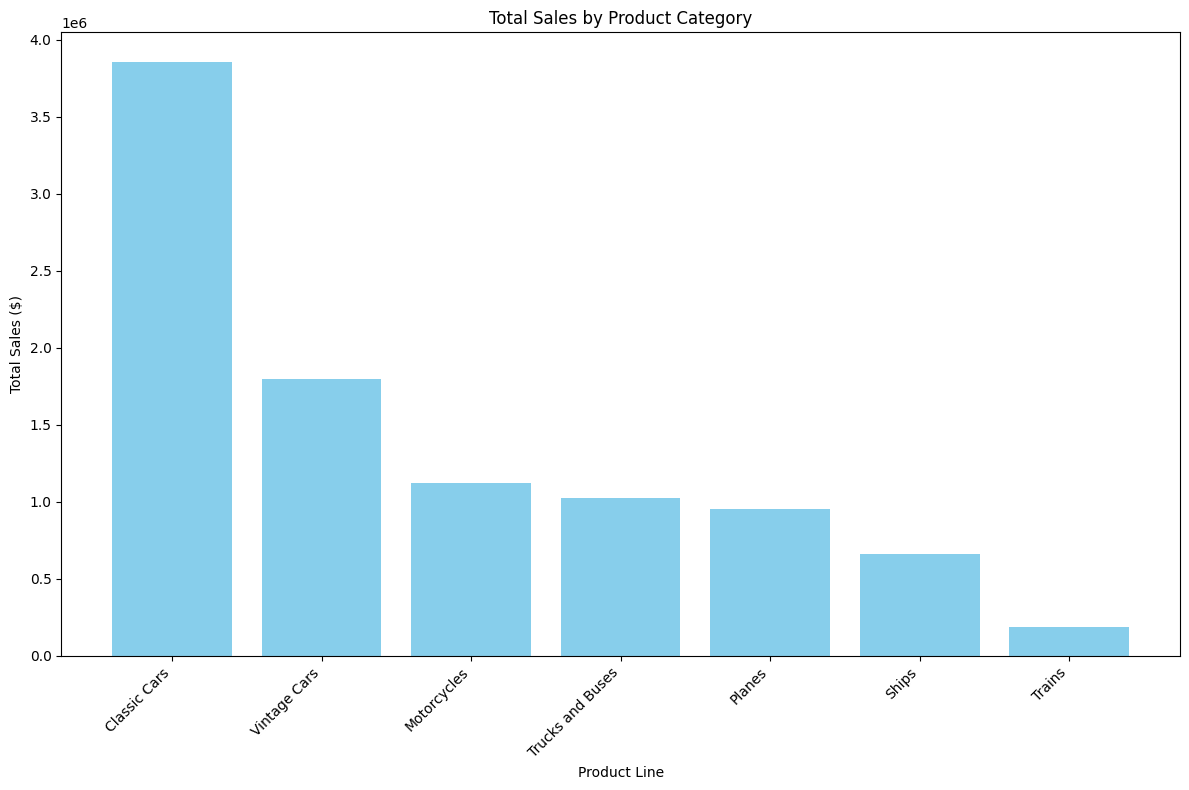

In [10]:
# 총 매출 시각화
plt.figure(figsize=(12, 8))
plt.bar(category_sales_df['productLine'], category_sales_df['total_sales'], color='skyblue')
plt.xlabel('Product Line')
plt.ylabel('Total Sales ($)')
plt.title('Total Sales by Product Category')
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

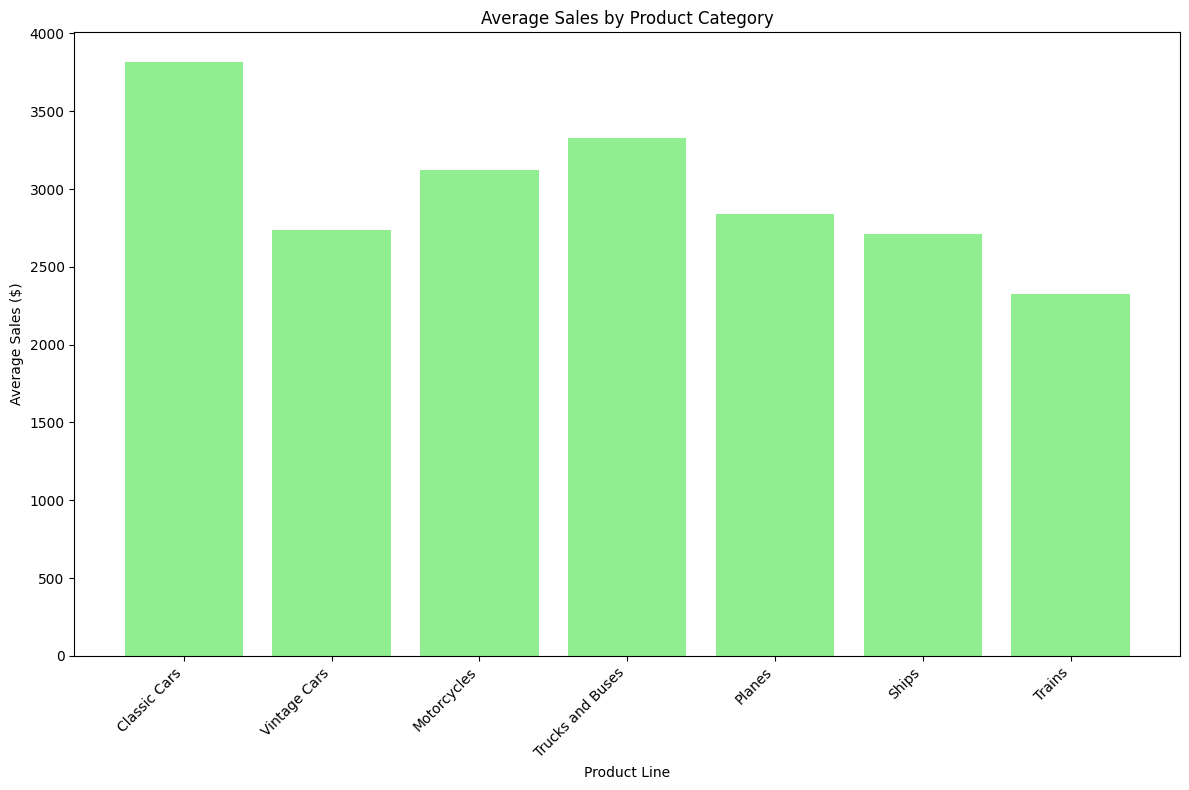

In [11]:
# 평균 매출 시각화
plt.figure(figsize=(12, 8))
plt.bar(category_sales_df['productLine'], category_sales_df['average_sales'], color='lightgreen')
plt.xlabel('Product Line')
plt.ylabel('Average Sales ($)')
plt.title('Average Sales by Product Category')
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()